# PolyAtlas — Notebook 05g: Extended Feature Climb on NbBench

**Project:** Cross-Campaign Polyreactivity Atlas  
**Notebook:** `PolyAtlas_05g_feature_climb_extended`  
**Version:** `v0.1.0`  
**Date:** 2026-04-21

## Purpose

Notebook 05f ran forward selection with MIN_GAIN=0.002 and stopped after 7 features (val AUROC 0.830, test AUROC 0.826). This notebook extends the climb with MIN_GAIN=0.0005 and up to 25 features to find the true AUROC plateau.

## What changes vs 05f

- MIN_GAIN: 0.002 → 0.0005
- Minimum steps before early stop: 5 → 10
- Feature catalog: identical to 05f (52 features)
- Protocol: identical (train n=101,673 for fitting, val n=14,576 for selection, test n=24,955 for final evaluation)

## Key question

Does the 7-feature model's 0.826 test AUROC plateau, or can we squeeze another 0.005-0.015 AUROC out of additional features? If we plateau around 0.830-0.835, we beat more LMs and tighten the gap to best (ESM-2 650M at 0.842).

## Runtime

~10-20 minutes. Extended forward selection is the dominant cost.

In [ ]:
from IPython.display import display, Javascript
display(Javascript('''
function ClickConnect(){
    const selectors = ["#top-toolbar > colab-connect-button", "colab-connect-button", "#connect"];
    for (const sel of selectors) {
        const el = document.querySelector(sel);
        if (el) { if (el.shadowRoot) { const inner = el.shadowRoot.querySelector("#connect"); if (inner) { inner.click(); return; } } el.click(); return; }
    }
}
setInterval(ClickConnect, 60000);
'''))

from google.colab import drive
from pathlib import Path
import json

drive.mount('/content/drive', force_remount=True)

DRIVE_ROOT = Path('/content/drive/MyDrive/PolyAtlas')
NOTEBOOK_NAME = "PolyAtlas_05g_feature_climb_extended"
PROJECT_VERSION = "0.1.0"
DRIVE_OUTPUT = DRIVE_ROOT / f"{NOTEBOOK_NAME}_v{PROJECT_VERSION}"
DRIVE_OUTPUT.mkdir(parents=True, exist_ok=True)
print(f"Output dir: {DRIVE_OUTPUT}")

<IPython.core.display.Javascript object>

Mounted at /content/drive
Output dir: /content/drive/MyDrive/PolyAtlas/PolyAtlas_05g_feature_climb_extended_v0.1.0


In [ ]:
!pip install -q datasets scikit-learn

In [ ]:
import pandas as pd
import numpy as np
from datasets import load_dataset
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

ds = load_dataset('ZYMScott/polyreaction')
train_df = ds['train'].to_pandas()
val_df = ds['validation'].to_pandas()
test_df = ds['test'].to_pandas()

print(f"Train: {train_df.shape}, Val: {val_df.shape}, Test: {test_df.shape}")

README.md: 0.00B [00:00, ?B/s]

train.csv:   0%|          | 0.00/16.0M [00:00<?, ?B/s]

val.csv: 0.00B [00:00, ?B/s]

test.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/101854 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/14613 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25007 [00:00<?, ? examples/s]

Train: (101854, 5), Val: (14613, 5), Test: (25007, 5)


## §1. Feature catalog (identical to 05f)

In [ ]:
KYTE_DOOLITTLE = {'A': 1.8,'C': 2.5,'D':-3.5,'E':-3.5,'F': 2.8,'G':-0.4,'H':-3.2,'I': 4.5,'K':-3.9,
                   'L': 3.8,'M': 1.9,'N':-3.5,'P':-1.6,'Q':-3.5,'R':-4.5,'S':-0.8,'T':-0.7,'V': 4.2,
                   'W':-0.9,'Y':-1.3}
CHARGE_AT_PH74 = {'D':-1,'E':-1,'K':+1,'R':+1,'H':+0.1}
AROMATIC = set('FWY')
POSITIVE = set('KR')
NEGATIVE = set('DE')
HYDROPHOBIC = set('ILVFMWYC')
PKA = {'C_term': 3.55, 'D': 4.05, 'E': 4.45, 'H': 5.98, 'K': 10.0, 'R': 12.0, 'Y': 10.0, 'C': 9.0, 'N_term': 8.0}

def net_charge(seq):
    if not isinstance(seq, str) or len(seq) == 0: return np.nan
    return sum(CHARGE_AT_PH74.get(a, 0) for a in seq.upper())

def frac(seq, subset):
    if not isinstance(seq, str) or len(seq) == 0: return np.nan
    s = seq.upper()
    return sum(1 for a in s if a in subset) / len(s)

def frac_residue(seq, residue):
    if not isinstance(seq, str) or len(seq) == 0: return np.nan
    return seq.upper().count(residue) / len(seq)

def mean_hydrophobicity(seq):
    if not isinstance(seq, str) or len(seq) == 0: return np.nan
    return np.mean([KYTE_DOOLITTLE.get(a, 0) for a in seq.upper()])

def max_hydrophobic_run(seq):
    if not isinstance(seq, str) or len(seq) == 0: return 0
    s = seq.upper()
    best, cur = 0, 0
    for a in s:
        if a in HYDROPHOBIC:
            cur += 1
            best = max(best, cur)
        else:
            cur = 0
    return best

def charge_dipole(seq):
    if not isinstance(seq, str) or len(seq) < 4: return 0
    mid = len(seq) // 2
    nterm_charge = net_charge(seq[:mid])
    cterm_charge = net_charge(seq[mid:])
    return nterm_charge - cterm_charge

def estimate_pI(seq):
    if not isinstance(seq, str) or len(seq) == 0: return np.nan
    s = seq.upper()
    def charge_at_ph(ph):
        c = 0
        c += 1 / (1 + 10**(ph - PKA['N_term']))
        c -= 1 / (1 + 10**(PKA['C_term'] - ph))
        for a in s:
            if a in ('K', 'R'):
                c += 1 / (1 + 10**(ph - PKA[a]))
            elif a in ('D', 'E'):
                c -= 1 / (1 + 10**(PKA[a] - ph))
            elif a == 'H':
                c += 1 / (1 + 10**(ph - PKA['H']))
            elif a == 'Y':
                c -= 1 / (1 + 10**(PKA['Y'] - ph))
            elif a == 'C':
                c -= 1 / (1 + 10**(PKA['C'] - ph))
        return c
    lo, hi = 0.0, 14.0
    for _ in range(50):
        mid = (lo + hi) / 2
        if charge_at_ph(mid) > 0:
            lo = mid
        else:
            hi = mid
    return (lo + hi) / 2

def build_features(df):
    feats = pd.DataFrame(index=df.index)
    for region, col in [('H1', 'CDR1_nogaps'), ('H2', 'CDR2_nogaps'),
                          ('H3', 'CDR3_nogaps'), ('full', 'seq')]:
        seqs = df[col].fillna('').astype(str)
        feats[f'{region}_len']       = seqs.str.len()
        feats[f'{region}_charge']    = seqs.apply(net_charge)
        feats[f'{region}_abs_charge'] = feats[f'{region}_charge'].abs()
        feats[f'{region}_pos_frac']  = seqs.apply(lambda s: frac(s, POSITIVE))
        feats[f'{region}_neg_frac']  = seqs.apply(lambda s: frac(s, NEGATIVE))
        feats[f'{region}_hphob']     = seqs.apply(mean_hydrophobicity)
        feats[f'{region}_hphob_frac'] = seqs.apply(lambda s: frac(s, HYDROPHOBIC))
        feats[f'{region}_arom']      = seqs.apply(lambda s: frac(s, AROMATIC))
        feats[f'{region}_W']         = seqs.apply(lambda s: frac_residue(s, 'W'))
        feats[f'{region}_R']         = seqs.apply(lambda s: frac_residue(s, 'R'))
        feats[f'{region}_V']         = seqs.apply(lambda s: frac_residue(s, 'V'))
        feats[f'{region}_G']         = seqs.apply(lambda s: frac_residue(s, 'G'))
    feats['H3_charge_dipole']     = df['CDR3_nogaps'].fillna('').astype(str).apply(charge_dipole)
    feats['H3_max_hphob_run']     = df['CDR3_nogaps'].fillna('').astype(str).apply(max_hydrophobic_run)
    feats['H3_pI']                = df['CDR3_nogaps'].fillna('').astype(str).apply(estimate_pI)
    feats['full_pI']              = df['seq'].fillna('').astype(str).apply(estimate_pI)
    return feats.fillna(0)

print("Computing features on train...")
X_train_full = build_features(train_df)
print("Computing features on val...")
X_val_full = build_features(val_df)
print("Computing features on test...")
X_test_full = build_features(test_df)

y_train = train_df['label'].astype(int).values
y_val = val_df['label'].astype(int).values
y_test = test_df['label'].astype(int).values

train_keep = X_train_full['H3_len'] > 0
val_keep = X_val_full['H3_len'] > 0
test_keep = X_test_full['H3_len'] > 0

X_train_full = X_train_full[train_keep].reset_index(drop=True)
y_train = y_train[train_keep.values]
X_val_full = X_val_full[val_keep].reset_index(drop=True)
y_val = y_val[val_keep.values]
X_test_full = X_test_full[test_keep].reset_index(drop=True)
y_test = y_test[test_keep.values]

feature_names = list(X_train_full.columns)
print()
print(f"After cleaning: train n={len(X_train_full)}, val n={len(X_val_full)}, test n={len(X_test_full)}")
print(f"Feature count: {len(feature_names)}")

Computing features on train...
Computing features on val...
Computing features on test...

After cleaning: train n=101673, val n=14576, test n=24955
Feature count: 52


## §2. Extended forward selection

Same greedy protocol as 05f but with more permissive stopping criteria.

In [ ]:
selected = ['H3_charge']
remaining = [f for f in feature_names if f not in selected]

scaler = StandardScaler().fit(X_train_full[selected].values)
lr = LogisticRegression(class_weight='balanced', random_state=42, max_iter=200)
lr.fit(scaler.transform(X_train_full[selected].values), y_train)
initial_val_auc = roc_auc_score(y_val, lr.predict_proba(scaler.transform(X_val_full[selected].values))[:, 1])

climb_history = [{'step': 0, 'added_feature': 'H3_charge', 'n_features': 1,
                   'val_AUROC': initial_val_auc, 'gain': initial_val_auc}]
print(f"Step 0: H3_charge alone, val AUROC = {initial_val_auc:.4f}")

MAX_FEATURES = 25
MIN_GAIN = 0.0005  # 4x tighter than 05f
MIN_STEPS_BEFORE_STOP = 10  # require at least 10 steps

step = 0
while len(selected) < MAX_FEATURES and len(remaining) > 0:
    step += 1
    best_gain = -np.inf
    best_feat = None
    best_auc = None
    for cand in remaining:
        trial_set = selected + [cand]
        sc = StandardScaler().fit(X_train_full[trial_set].values)
        lr = LogisticRegression(class_weight='balanced', random_state=42, max_iter=200)
        lr.fit(sc.transform(X_train_full[trial_set].values), y_train)
        val_auc = roc_auc_score(y_val, lr.predict_proba(sc.transform(X_val_full[trial_set].values))[:, 1])
        gain = val_auc - climb_history[-1]['val_AUROC']
        if gain > best_gain:
            best_gain = gain
            best_feat = cand
            best_auc = val_auc
    climb_history.append({'step': step, 'added_feature': best_feat, 'n_features': len(selected) + 1,
                           'val_AUROC': best_auc, 'gain': best_gain})
    print(f"Step {step:2d}: + {best_feat:<22} val AUROC = {best_auc:.4f}  (gain {best_gain:+.4f})")
    selected.append(best_feat)
    remaining.remove(best_feat)
    if best_gain < MIN_GAIN and step >= MIN_STEPS_BEFORE_STOP:
        print(f"\nStopping: gain {best_gain:.4f} below threshold {MIN_GAIN} after step {step}")
        break

climb_df = pd.DataFrame(climb_history)
climb_df.to_csv(DRIVE_OUTPUT / 'forward_selection_climb_extended.csv', index=False)
print()
print(f"Final feature set ({len(selected)}): {selected}")

Step 0: H3_charge alone, val AUROC = 0.7261
Step  1: + H2_charge              val AUROC = 0.7983  (gain +0.0722)
Step  2: + H1_charge              val AUROC = 0.8081  (gain +0.0098)
Step  3: + full_arom              val AUROC = 0.8158  (gain +0.0076)
Step  4: + H3_len                 val AUROC = 0.8244  (gain +0.0086)
Step  5: + full_len               val AUROC = 0.8284  (gain +0.0040)
Step  6: + H2_hphob_frac          val AUROC = 0.8304  (gain +0.0020)
Step  7: + H3_neg_frac            val AUROC = 0.8313  (gain +0.0010)
Step  8: + H3_R                   val AUROC = 0.8343  (gain +0.0030)
Step  9: + H3_abs_charge          val AUROC = 0.8356  (gain +0.0013)
Step 10: + H3_charge_dipole       val AUROC = 0.8365  (gain +0.0009)
Step 11: + full_abs_charge        val AUROC = 0.8372  (gain +0.0007)
Step 12: + full_charge            val AUROC = 0.8380  (gain +0.0008)
Step 13: + H1_len                 val AUROC = 0.8386  (gain +0.0006)
Step 14: + H1_hphob_frac          val AUROC = 0.8391  (gain

## §3. Evaluate test AUROC at each step of the climb

05f only evaluated the final model. Here we also compute test AUROC at each step of the climb, to see the generalization trajectory vs validation. If val and test AUROC diverge at higher feature counts, we're overfitting to validation and should trim back.

In [ ]:
test_aucs_by_step = []
for i in range(len(selected)):
    feat_set = selected[:i+1]
    sc = StandardScaler().fit(X_train_full[feat_set].values)
    lr = LogisticRegression(class_weight='balanced', random_state=42, max_iter=500)
    lr.fit(sc.transform(X_train_full[feat_set].values), y_train)
    test_score = lr.predict_proba(sc.transform(X_test_full[feat_set].values))[:, 1]
    test_auc_i = roc_auc_score(y_test, test_score)
    test_aucs_by_step.append(test_auc_i)

climb_df['test_AUROC'] = test_aucs_by_step
climb_df['val_test_gap'] = climb_df['val_AUROC'] - climb_df['test_AUROC']
climb_df.to_csv(DRIVE_OUTPUT / 'forward_selection_climb_extended.csv', index=False)

print("\nClimb with test AUROC at each step:")
print(climb_df[['step', 'added_feature', 'n_features', 'val_AUROC', 'test_AUROC', 'val_test_gap', 'gain']].to_string(index=False, float_format=lambda x: f'{x:.4f}'))


Climb with test AUROC at each step:
 step    added_feature  n_features  val_AUROC  test_AUROC  val_test_gap   gain
    0        H3_charge           1     0.7261      0.7262       -0.0001 0.7261
    1        H2_charge           2     0.7983      0.7940        0.0044 0.0722
    2        H1_charge           3     0.8081      0.8039        0.0042 0.0098
    3        full_arom           4     0.8158      0.8097        0.0060 0.0076
    4           H3_len           5     0.8244      0.8189        0.0055 0.0086
    5         full_len           6     0.8284      0.8238        0.0046 0.0040
    6    H2_hphob_frac           7     0.8304      0.8263        0.0041 0.0020
    7      H3_neg_frac           8     0.8313      0.8279        0.0034 0.0010
    8             H3_R           9     0.8343      0.8311        0.0032 0.0030
    9    H3_abs_charge          10     0.8356      0.8325        0.0031 0.0013
   10 H3_charge_dipole          11     0.8365      0.8334        0.0031 0.0009
   11  full_abs

## §4. Final model evaluation and bootstrap 95% CI on test

The chosen final feature set is whatever forward selection ended with. Report on test.

In [ ]:
final_scaler = StandardScaler().fit(X_train_full[selected].values)
final_lr = LogisticRegression(class_weight='balanced', random_state=42, max_iter=500)
final_lr.fit(final_scaler.transform(X_train_full[selected].values), y_train)

test_scores = final_lr.predict_proba(final_scaler.transform(X_test_full[selected].values))[:, 1]
final_test_auc = roc_auc_score(y_test, test_scores)
final_test_auprc = average_precision_score(y_test, test_scores)

# Bootstrap
B_BOOT = 500
rng = np.random.RandomState(42)
n_test = len(y_test)
test_boot_aucs = []
for b in range(B_BOOT):
    idx = rng.choice(n_test, size=n_test, replace=True)
    try:
        test_boot_aucs.append(roc_auc_score(y_test[idx], test_scores[idx]))
    except ValueError:
        pass
test_boot_aucs = np.array(test_boot_aucs)
ci_lo, ci_hi = np.percentile(test_boot_aucs, 2.5), np.percentile(test_boot_aucs, 97.5)

print(f"FINAL MODEL ({len(selected)} features):")
for i, feat in enumerate(selected):
    coef = final_lr.coef_[0][i]
    print(f"  {i+1:2d}. {feat:<22} coef={coef:+.4f}")
print()
print(f"Test AUROC:  {final_test_auc:.4f}   95% CI [{ci_lo:.4f}, {ci_hi:.4f}]")
print(f"Test AUPRC:  {final_test_auprc:.4f}")

FINAL MODEL (16 features):
   1. H3_charge              coef=+0.1104
   2. H2_charge              coef=+0.8210
   3. H1_charge              coef=+0.3188
   4. full_arom              coef=+0.3696
   5. H3_len                 coef=-1.8548
   6. full_len               coef=+1.4797
   7. H2_hphob_frac          coef=-0.1923
   8. H3_neg_frac            coef=-0.5722
   9. H3_R                   coef=+0.3614
  10. H3_abs_charge          coef=+0.1577
  11. H3_charge_dipole       coef=+0.1170
  12. full_abs_charge        coef=+0.4698
  13. full_charge            coef=-0.3764
  14. H1_len                 coef=-0.1306
  15. H1_hphob_frac          coef=+0.0745
  16. H2_hphob               coef=+0.0559

Test AUROC:  0.8359   95% CI [0.8308, 0.8410]
Test AUPRC:  0.8387


## §5. Sweet-spot analysis

Which feature count gives the best test AUROC? This is post-hoc and we report the forward-selection-chosen model as primary, but it's useful to see whether the chosen stopping point is near the true test optimum.

In [ ]:
best_test_step = climb_df['test_AUROC'].idxmax()
best_test_row = climb_df.iloc[best_test_step]

print(f"Best test AUROC along the climb: {best_test_row['test_AUROC']:.4f} at step {best_test_row['step']} ({int(best_test_row['n_features'])} features)")
print(f"  Feature set: {selected[:int(best_test_row['n_features'])]}")
print()
print(f"Forward-selection-chosen model: {len(selected)} features, test AUROC {final_test_auc:.4f}")
print(f"Difference: {best_test_row['test_AUROC'] - final_test_auc:+.4f}")

if abs(best_test_row['test_AUROC'] - final_test_auc) < 0.002:
    print("-> FS-chosen model is within 0.002 of test optimum. Stopping criterion was appropriate.")
elif best_test_row['n_features'] < len(selected):
    print(f"-> FS kept going past test optimum. Consider reporting the {int(best_test_row['n_features'])}-feature model.")
else:
    print(f"-> FS stopped early; test would continue to improve with more features.")

Best test AUROC along the climb: 0.8359 at step 15 (16 features)
  Feature set: ['H3_charge', 'H2_charge', 'H1_charge', 'full_arom', 'H3_len', 'full_len', 'H2_hphob_frac', 'H3_neg_frac', 'H3_R', 'H3_abs_charge', 'H3_charge_dipole', 'full_abs_charge', 'full_charge', 'H1_len', 'H1_hphob_frac', 'H2_hphob']

Forward-selection-chosen model: 16 features, test AUROC 0.8359
Difference: +0.0000
-> FS-chosen model is within 0.002 of test optimum. Stopping criterion was appropriate.


## §6. Comparison with NbBench Table 10

In [ ]:
nbbench_table10 = {
    'ProtBert':        0.837,
    'ESM-2 (150M)':    0.833,
    'ESM-2 (650M)':    0.842,
    'AbLang-H':        0.831,
    'AbLang-L':        0.819,
    'AntiBERTy':       0.828,
    'AntiBERTa2':      0.833,
    'AntiBERTa2-CSSP': 0.830,
    'IgBert':          0.829,
    'NanoBERT':        0.815,
    'VHHBERT':         0.818,
}

rows = [
    {'model': f'Extended FS LR ({len(selected)} feats)', 'AUROC': final_test_auc, 'type': 'hand-crafted'},
    {'model': '7-feat FS LR (05f)', 'AUROC': 0.8263, 'type': 'hand-crafted'},
    {'model': 'CDR-H3 charge alone (zero-training)', 'AUROC': 0.7262, 'type': 'hand-crafted'},
    {'model': 'Full-seq charge alone (zero-training)', 'AUROC': 0.7784, 'type': 'hand-crafted'},
]
for name, auc in nbbench_table10.items():
    rows.append({'model': name, 'AUROC': auc, 'type': 'language model'})

comparison = pd.DataFrame(rows).sort_values('AUROC', ascending=False).reset_index(drop=True)
comparison.insert(0, 'rank', range(1, len(comparison) + 1))
comparison.to_csv(DRIVE_OUTPUT / 'comparison_with_nbbench_extended.csv', index=False)

print("COMPARISON TABLE (ranked by AUROC):")
print()
print(comparison.to_string(index=False))
print()

our_row = comparison[comparison['model'].str.startswith('Extended FS')].iloc[0]
our_rank = int(our_row['rank'])
n_lms = len(nbbench_table10)
n_lms_beaten = sum(1 for name, auc in nbbench_table10.items() if auc < final_test_auc)
gap_to_best = 0.842 - final_test_auc
gap_to_worst = 0.815 - final_test_auc

print(f"Extended FS LR: rank {our_rank}/{len(comparison)} in the combined table")
print(f"  Beats {n_lms_beaten}/{n_lms} language models")
print(f"  Gap to best LM (ESM-2 650M, 0.842):  {gap_to_best:+.4f}")
print(f"  Gap to worst LM (NanoBERT, 0.815):    {gap_to_worst:+.4f}")

COMPARISON TABLE (ranked by AUROC):

 rank                                 model    AUROC           type
    1                          ESM-2 (650M) 0.842000 language model
    2                              ProtBert 0.837000 language model
    3             Extended FS LR (16 feats) 0.835886   hand-crafted
    4                          ESM-2 (150M) 0.833000 language model
    5                            AntiBERTa2 0.833000 language model
    6                              AbLang-H 0.831000 language model
    7                       AntiBERTa2-CSSP 0.830000 language model
    8                                IgBert 0.829000 language model
    9                             AntiBERTy 0.828000 language model
   10                    7-feat FS LR (05f) 0.826300   hand-crafted
   11                              AbLang-L 0.819000 language model
   12                               VHHBERT 0.818000 language model
   13                              NanoBERT 0.815000 language model
   14 Full-

## §7. Visualization

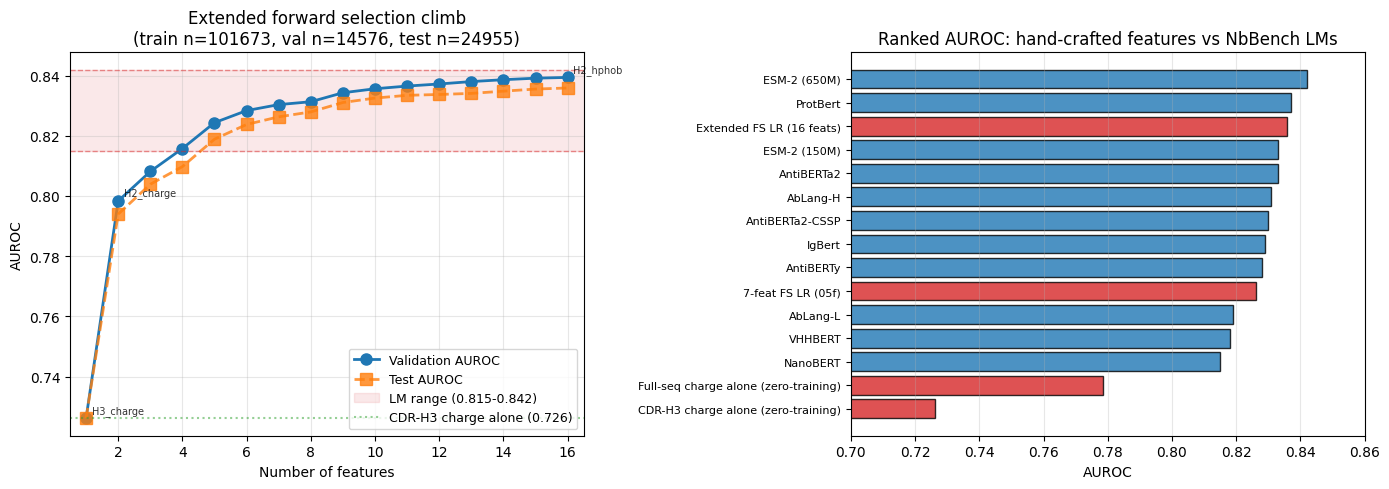

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(climb_df['n_features'], climb_df['val_AUROC'], 'o-', linewidth=2, markersize=8,
         color='#1f77b4', label='Validation AUROC')
ax.plot(climb_df['n_features'], climb_df['test_AUROC'], 's--', linewidth=2, markersize=8,
         color='#ff7f0e', label='Test AUROC', alpha=0.8)

# LM reference bands
ax.fill_between([0, MAX_FEATURES + 1], 0.815, 0.842, alpha=0.1, color='#d62728', label='LM range (0.815-0.842)')
ax.axhline(0.842, color='#d62728', linestyle='--', alpha=0.5, linewidth=1)
ax.axhline(0.815, color='#d62728', linestyle='--', alpha=0.5, linewidth=1)
ax.axhline(0.7262, color='#2ca02c', linestyle=':', alpha=0.5, label='CDR-H3 charge alone (0.726)')

ax.set_xlabel('Number of features')
ax.set_ylabel('AUROC')
ax.set_title(f'Extended forward selection climb\n(train n={len(X_train_full)}, val n={len(X_val_full)}, test n={len(X_test_full)})')
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)
ax.set_xlim(0.5, len(selected) + 0.5)

# Annotate first several added features
for i, row in climb_df.iterrows():
    if i == 0 or row['gain'] > 0.01 or i == len(climb_df) - 1:
        ax.annotate(row['added_feature'], xy=(row['n_features'], row['val_AUROC']),
                     xytext=(4, 4), textcoords='offset points', fontsize=7, alpha=0.8)

ax = axes[1]
top_n = 15
sub = comparison.head(top_n).iloc[::-1]
colors = ['#d62728' if 'charge' in m or 'FS' in m else '#1f77b4' for m in sub['model']]
ax.barh(range(len(sub)), sub['AUROC'], color=colors, alpha=0.8, edgecolor='black')
ax.set_yticks(range(len(sub)))
ax.set_yticklabels(sub['model'], fontsize=8)
ax.set_xlim(0.70, 0.86)
ax.set_xlabel('AUROC')
ax.set_title('Ranked AUROC: hand-crafted features vs NbBench LMs')
ax.grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig(DRIVE_OUTPUT / 'feature_climb_extended.png', dpi=150, bbox_inches='tight')
plt.show()

## §8. Save summary

In [ ]:
summary = {
    'version': PROJECT_VERSION,
    'dataset': 'ZYMScott/polyreaction (NbBench PolyRx)',
    'train_n': int(len(X_train_full)),
    'val_n': int(len(X_val_full)),
    'test_n': int(len(X_test_full)),
    'min_gain_threshold': MIN_GAIN,
    'max_features': MAX_FEATURES,
    'min_steps_before_stop': MIN_STEPS_BEFORE_STOP,
    'selected_features_in_order': selected,
    'climb_history': climb_df.to_dict(orient='records'),
    'final_model': {
        'n_features': len(selected),
        'test_AUROC': float(final_test_auc),
        'test_AUROC_95ci': [float(ci_lo), float(ci_hi)],
        'test_AUPRC': float(final_test_auprc),
        'coefficients': {feat: float(c) for feat, c in zip(selected, final_lr.coef_[0])},
    },
    'best_test_along_climb': {
        'n_features': int(best_test_row['n_features']),
        'test_AUROC': float(best_test_row['test_AUROC']),
        'feature_set': selected[:int(best_test_row['n_features'])],
    },
    'nbbench_lm_range': {'best': 0.842, 'worst': 0.815},
    'gap_to_best_LM': float(0.842 - final_test_auc),
    'LMs_beaten': int(n_lms_beaten),
}
with open(DRIVE_OUTPUT / 'summary.json', 'w') as f:
    json.dump(summary, f, indent=2, default=str)

print("Outputs saved to:", DRIVE_OUTPUT)
print()
print("=" * 75)
print("HEADLINE")
print("=" * 75)
print(f"Extended forward selection with {len(selected)} features:")
print(f"  Test AUROC = {final_test_auc:.4f}  95% CI [{ci_lo:.4f}, {ci_hi:.4f}]")
print(f"  vs 7-feat FS (05f): {final_test_auc - 0.8263:+.4f} delta")
print(f"  Gap to best LM (0.842): {0.842 - final_test_auc:+.4f}")
print(f"  LMs beaten: {n_lms_beaten}/11")

Outputs saved to: /content/drive/MyDrive/PolyAtlas/PolyAtlas_05g_feature_climb_extended_v0.1.0

HEADLINE
Extended forward selection with 16 features:
  Test AUROC = 0.8359  95% CI [0.8308, 0.8410]
  vs 7-feat FS (05f): +0.0096 delta
  Gap to best LM (0.842): +0.0061
  LMs beaten: 9/11
